In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [17]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [18]:
len(words)

32033

In [19]:
# build the vocabulary characters and mapping to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [20]:
# build the dataset 
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y=[],[]
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix] #crop and append  

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [21]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [22]:
C = torch.randn((27,2))
C[5]


tensor([-1.3978, -0.7803])

In [23]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-1.3978, -0.7803])

In [24]:
C[X].shape

torch.Size([32, 3, 2])

In [25]:
X[13,2]

tensor(1)

In [26]:
C[X][13,2]

tensor([-1.0723,  2.4403])

In [27]:
C[1]

tensor([-1.0723,  2.4403])

In [28]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [29]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [30]:
# emb @ w1 + b1

In [31]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [32]:
torch.unbind(emb,1)

(tensor([[-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.3978e+00, -7.8026e-01],
         [-1.6668e-02, -4.9026e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-5.8241e-01, -2.6651e-01],
         [ 3.9669e-01,  6.6795e-04],
         [ 1.3744e+00, -9.1589e-01],
         [ 1.0422e+00, -2.2134e+00],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0723e+00,  2.4403e+00],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
         [ 1.3744e+00, -9.1589e-01],
         [-1.9849e-01,  4.1372e-01],
         [-1.0723e+00,  2.4403e+00],
         [ 1.2166e+00, -6.0475e-01],
         [-1.3978e+00, -7.8026e-01],
         [ 3.9669e-01,  6.6795e-04],
         [-1.0553e+00,  9.3631e-01],
         [-1.0553e+00,  9.3631e-01],
 

In [33]:
torch.cat((torch.unbind(emb,1)),1)

tensor([[-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.0553e+00,
          9.3631e-01],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.3978e+00,
         -7.8026e-01],
        [-1.0553e+00,  9.3631e-01, -1.3978e+00, -7.8026e-01, -1.6668e-02,
         -4.9026e-01],
        [-1.3978e+00, -7.8026e-01, -1.6668e-02, -4.9026e-01, -1.6668e-02,
         -4.9026e-01],
        [-1.6668e-02, -4.9026e-01, -1.6668e-02, -4.9026e-01, -1.0723e+00,
          2.4403e+00],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.0553e+00,
          9.3631e-01],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -5.8241e-01,
         -2.6651e-01],
        [-1.0553e+00,  9.3631e-01, -5.8241e-01, -2.6651e-01,  3.9669e-01,
          6.6795e-04],
        [-5.8241e-01, -2.6651e-01,  3.9669e-01,  6.6795e-04,  1.3744e+00,
         -9.1589e-01],
        [ 3.9669e-01,  6.6795e-04,  1.3744e+00, -9.1589e-01,  1.0422e+00,
         -2.2134e+00],
        [ 1.3744e+00, -9.1589e

In [34]:
torch.cat((torch.unbind(emb,1)),1).shape

torch.Size([32, 6])

In [35]:
a = torch.arange(18)

In [36]:
a.shape

torch.Size([18])

In [37]:
# a.view(9,2)
# a.view(2,9)
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [38]:
a.storage

<bound method Tensor.storage of tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])>

In [39]:
emb.shape

torch.Size([32, 3, 2])

In [40]:
emb.view(32,6)

tensor([[-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.0553e+00,
          9.3631e-01],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.3978e+00,
         -7.8026e-01],
        [-1.0553e+00,  9.3631e-01, -1.3978e+00, -7.8026e-01, -1.6668e-02,
         -4.9026e-01],
        [-1.3978e+00, -7.8026e-01, -1.6668e-02, -4.9026e-01, -1.6668e-02,
         -4.9026e-01],
        [-1.6668e-02, -4.9026e-01, -1.6668e-02, -4.9026e-01, -1.0723e+00,
          2.4403e+00],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -1.0553e+00,
          9.3631e-01],
        [-1.0553e+00,  9.3631e-01, -1.0553e+00,  9.3631e-01, -5.8241e-01,
         -2.6651e-01],
        [-1.0553e+00,  9.3631e-01, -5.8241e-01, -2.6651e-01,  3.9669e-01,
          6.6795e-04],
        [-5.8241e-01, -2.6651e-01,  3.9669e-01,  6.6795e-04,  1.3744e+00,
         -9.1589e-01],
        [ 3.9669e-01,  6.6795e-04,  1.3744e+00, -9.1589e-01,  1.0422e+00,
         -2.2134e+00],
        [ 1.3744e+00, -9.1589e

In [41]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [42]:
# h = emb.view(32,6) @w1+b1 # this creates new memory to avoid use the following 

In [43]:
# h.shape

In [44]:
h = torch.tanh(emb.view(-1,6) @ w1+b1)

In [45]:
h

tensor([[-0.8441,  0.9998,  0.5794,  ..., -0.9831, -0.9995, -0.9562],
        [ 0.4636,  0.9996,  0.5545,  ..., -0.5579, -1.0000, -0.9996],
        [-0.4106,  0.5718, -0.9843,  ..., -0.9510, -0.7058, -0.9925],
        ...,
        [-0.9305, -0.9973, -0.8836,  ..., -0.9931,  0.9197,  0.8403],
        [-0.5168, -0.9999,  0.3119,  ..., -0.0504,  0.9984,  0.9940],
        [-0.9999, -0.5107,  0.9904,  ..., -0.9727, -0.9715,  0.6622]])

In [46]:
h.shape

torch.Size([32, 100])

In [47]:
w2 = torch.randn((100,27))
b2 = torch.randn(27)

In [48]:
logits = h @ w2 + b2

In [49]:
logits.shape

torch.Size([32, 27])

In [50]:
logits

tensor([[-3.2839e+00, -3.0961e+00,  9.3242e+00,  1.6280e+00, -6.6005e+00,
          7.5967e-01, -6.4717e+00, -1.3074e+01,  4.8477e+00, -1.7626e+00,
          9.9547e+00,  6.1385e+00,  1.1570e+01, -5.8380e+00,  2.9223e+00,
         -8.7892e+00,  4.0634e+00, -1.7547e+00, -3.4488e+00, -7.8805e+00,
         -1.1446e+01,  6.0273e+00,  7.2239e+00,  6.1760e-02,  1.2349e+00,
          1.4288e+01, -4.9802e+00],
        [-1.3045e+01, -4.7308e+00, -6.1667e-01, -5.9865e+00, -1.8616e+00,
         -2.7560e-01, -1.0946e+01, -1.6992e+01,  1.6961e+00, -4.0447e+00,
          8.2627e+00,  2.1456e+00,  6.1436e+00, -5.1863e-01,  5.8249e+00,
          4.6174e-02,  7.8074e+00, -5.6095e+00,  1.1892e+01, -1.1537e+01,
         -7.7037e+00, -8.7029e+00,  5.7965e+00,  1.2488e+00, -8.8513e+00,
          1.0609e+01, -6.5427e+00],
        [-1.2124e+01,  5.7481e+00, -3.3613e+00,  6.4750e+00, -2.8595e+00,
         -2.4547e+00, -1.3269e+01, -2.2269e+00, -1.2149e+01, -7.2240e+00,
          2.7553e+00, -6.2861e-02,  1.55

In [51]:
counts = logits.exp()

In [52]:
prob = counts / counts.sum(1, keepdims=True)

In [53]:
prob.shape

torch.Size([32, 27])

In [54]:
prob

tensor([[2.1487e-08, 2.5928e-08, 6.4244e-03, 2.9200e-06, 7.7950e-10, 1.2254e-06,
         8.8659e-10, 1.2036e-12, 7.3063e-05, 9.8373e-08, 1.2068e-02, 2.6564e-04,
         6.0691e-02, 1.6709e-09, 1.0654e-05, 8.7351e-11, 3.3350e-05, 9.9151e-08,
         1.8220e-08, 2.1673e-10, 6.1273e-12, 2.3767e-04, 7.8641e-04, 6.0980e-07,
         1.9709e-06, 9.1940e-01, 3.9398e-09],
        [1.1138e-11, 4.5461e-08, 2.7822e-06, 1.2951e-08, 8.0116e-07, 3.9130e-06,
         9.0840e-11, 2.1511e-13, 2.8107e-05, 9.0282e-08, 1.9983e-02, 4.4059e-05,
         2.4007e-03, 3.0687e-06, 1.7455e-03, 5.3982e-06, 1.2674e-02, 1.8880e-08,
         7.5272e-01, 5.0324e-11, 2.3255e-09, 8.5619e-10, 1.6966e-03, 1.7969e-05,
         7.3814e-10, 2.0867e-01, 7.4255e-09],
        [7.0658e-16, 4.0828e-08, 4.5165e-12, 8.4462e-08, 7.4605e-12, 1.1182e-11,
         2.2481e-16, 1.4043e-11, 6.8911e-16, 9.4904e-14, 2.0475e-09, 1.2227e-10,
         7.7254e-04, 1.3455e-05, 2.4785e-12, 2.7722e-09, 1.7362e-17, 5.5147e-14,
         2.2699e-

In [55]:
prob[1].sum()

tensor(1.0000)

In [56]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [57]:
Y


tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [58]:
prob[torch.arange(32),Y]

tensor([1.2254e-06, 3.0687e-06, 1.3455e-05, 1.9697e-08, 7.2047e-09, 8.7351e-11,
        9.9401e-01, 2.8229e-10, 1.0898e-04, 1.1785e-07, 7.9413e-11, 1.7324e-08,
        2.5928e-08, 2.4371e-03, 2.0783e-12, 1.0798e-07, 9.8373e-08, 2.8978e-16,
        2.6752e-08, 9.1219e-02, 6.5003e-12, 1.2781e-10, 3.7176e-01, 1.0116e-02,
        1.4900e-07, 2.1673e-10, 2.8677e-15, 2.3131e-08, 4.1932e-14, 8.8672e-08,
        1.1516e-05, 9.8783e-08])

In [59]:
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(16.9140)

In [60]:
#---------- now made respectable : --------------

In [61]:
X.shape,Y.shape #dataset

(torch.Size([32, 3]), torch.Size([32]))

In [62]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [63]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [64]:
for p in parameters:
    p.requires_grad = True

In [71]:
for _ in range(1000):
    # forward pass
    emb = C[X] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())



0.255561888217926


In [66]:
logits = torch.tensor([-100,-3,0,100])
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([0., 0., 0., nan])

In [67]:
counts

tensor([3.7835e-44, 4.9787e-02, 1.0000e+00,        inf])

In [72]:
logits.max(1)

torch.return_types.max(
values=tensor([13.4206, 17.9792, 20.6837, 20.7368, 16.8675, 13.4206, 16.1245, 14.2801,
        16.0223, 18.5128, 16.0852, 21.0638, 13.4206, 17.2706, 17.2775, 20.2138,
        13.4206, 16.7157, 15.2712, 17.2145, 18.7032, 16.1175, 11.0066, 10.8034,
        15.5953, 13.4206, 16.2992, 17.0979, 12.8311, 16.2992, 19.2378, 16.2031],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [74]:
# build the dataset 
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y=[],[]
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix] #crop and append  

X = torch.tensor(X)
Y = torch.tensor(Y)

In [75]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [76]:
X.shape,Y.shape #dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [93]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [94]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [95]:
for p in parameters:
    p.requires_grad = True

In [81]:
for _ in range(10):
    # forward pass
    emb = C[X] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad




10.709587097167969
10.407631874084473
10.127808570861816
9.864364624023438
9.614501953125
9.376439094543457
9.148944854736328
8.931109428405762
8.722230911254883
8.521748542785645


In [82]:
torch.randint(0,X.shape[0],(32,))

tensor([147857,  30298, 218452,  74915, 152400, 157934,  72856, 118950,  88124,
         71245, 179969, 100402, 221722,  77372,  42327, 180729,  87055, 158482,
        222131, 112172, 215159, 119595, 227195, 168841, 142836, 222633,  41545,
        143290, 136353, 136079,  27298,  40162])

In [91]:
for _ in range(100):
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

2.755214214324951


In [92]:
emb = C[X[ix]] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Y[ix])
loss

tensor(2.2294, grad_fn=<NllLossBackward0>)

In [117]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

In [118]:
sum(p.nelement() for p in parameters) #numbers of parameters in total

3481

In [119]:
for p in parameters:
    p.requires_grad = True

In [120]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [115]:
lri = []
lossi = []
for i in range(1000):
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    lri.append(lre[i])
    lossi.append(loss.item())
# print(loss.item())

22.003738403320312
17.45255470275879
15.885149955749512
15.75298023223877
16.762876510620117
12.698135375976562
13.709972381591797
11.659994125366211
11.666773796081543
12.58666706085205
11.656408309936523
9.475478172302246
9.656824111938477
8.194267272949219
10.9100980758667
11.810275077819824
5.90549373626709
9.822638511657715
10.0107421875
10.396093368530273
7.908575057983398
7.598109245300293
10.056648254394531
8.14883041381836
9.199892044067383
7.417914390563965
8.476239204406738
8.324509620666504
6.567009925842285
7.432796478271484
6.9185404777526855
5.330115795135498
6.471800804138184
5.98474645614624
6.603761672973633
4.602927207946777
6.47756290435791
6.175477027893066
7.5844340324401855
5.625362873077393
6.322427749633789
5.204421520233154
5.610591888427734
5.46312952041626
6.759458065032959
5.10791015625
5.015916347503662
5.262337684631348
5.278197288513184
3.6867401599884033
5.888031959533691
4.749843597412109
3.544257640838623
3.9015347957611084
6.370107650756836
4.5244421

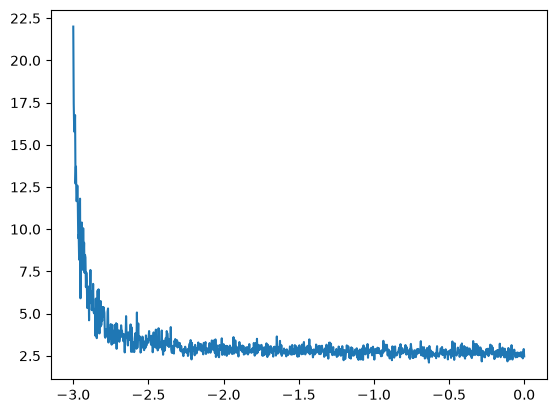

In [116]:
plt.plot(lri,lossi)

In [127]:
lri = []
lossi = []
for i in range(10000):
    ix = torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb = C[X[ix]] #(32,3,20
    h = torch.tanh(emb.view(-1,6)@ W1 + b1)
    logits = h @ W2 + b2 
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update 
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -0.1 * p.grad
    # track stat
    # lri.append(lre[i])
    # lossi.append(loss.item())
# print(loss.item())

In [128]:
emb = C[X[ix]] #(32,3,20
h = torch.tanh(emb.view(-1,6)@ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Y[ix])
loss

tensor(2.0391, grad_fn=<NllLossBackward0>)